# nb03 -- totalVI: joint RNA-protein model
Learn the RNA-protein relationship jointly (unsupervised), then use it to probe severity. RNA input = matched coupling genes (163) union top HVGs, so genes relevant to known RNA-protein pairs are kept even if not top-variance.

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata scvi-tools
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Mounted at /content/drive
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## Imports and config

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import scvi

CHECKPOINT_PATH = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
GENE_MAPPING_PATH = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
MODELS_DIR = BASE_PATH / 'results' / 'checkpoints'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

N_HVGS = 2000
DROP_GENES = ['PDPN', 'KDR']  # zero-variance in GEX (see nb02 Step 3b)

## Load checkpoint and gene mapping
Splits GEX/ADT and rebuilds the final 163-gene matched set (mirrors nb02 Step 3b) directly from the saved mapping, so this notebook is self-contained.

In [3]:
covid = sc.read_h5ad(CHECKPOINT_PATH)

gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'
covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
matched_genes = gene_map['gene'].tolist()
matched_adt_names = gene_map['adt_name'].tolist()

print(f'GEX: {covid_gex.shape}, ADT: {covid_adt.shape}')
print(f'Matched genes/proteins: {len(matched_genes)}')

GEX: (69090, 24737), ADT: (69090, 192)
Matched genes/proteins: 163


## HVG selection (on raw counts)
Standard top-variance genes, computed independently of the matched set.

In [4]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=N_HVGS, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()
print(f'HVGs selected: {len(hvg_genes)}')

HVGs selected: 2000


## Build gene union (matched genes always kept, even if not HVG)

In [5]:
def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
n_matched_not_hvg = len(set(matched_genes) - set(hvg_genes))
print(f'Gene union: {len(gene_union)} (matched-only additions: {n_matched_not_hvg})')

Gene union: 2092 (matched-only additions: 92)


## Subset RNA to gene union, attach protein counts for totalVI
Protein input stays the 163 matched proteins (the panel this study is about) -- totalVI uses all provided proteins regardless of RNA gene selection.

In [6]:
adata = covid_gex[:, gene_union].copy()

adt_counts = covid_adt[:, matched_adt_names].layers['raw']
adt_counts = np.asarray(adt_counts.todense()) if hasattr(adt_counts, 'todense') else np.asarray(adt_counts)
adata.obsm['protein_expression'] = adt_counts
adata.uns['protein_names'] = matched_adt_names

print(f'totalVI input: {adata.shape[0]} cells x {adata.shape[1]} genes, '
      f'{adt_counts.shape[1]} proteins')

totalVI input: 69090 cells x 2092 genes, 163 proteins


## Setup and train totalVI
`patient_id` as batch key -- lets the model account for patient-to-patient technical/biological variation, same variation that drove today's `CV0178`/`CV0198` findings.

In [8]:
scvi.model.TOTALVI.setup_anndata(
    adata,
    layer='counts',
    protein_expression_obsm_key='protein_expression',
    batch_key='patient_id',
)

model = scvi.model.TOTALVI(adata, n_latent=20)

INFO     Generating sequential column names                                                                        


--- Logging error ---
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/tornado/ioloop.py", line 758, in _run_callback
    ret = callback()
          ^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/iostream.py", line 518, in _flush
    self.session.send(
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 820, in send
    msg = self.msg(
          ^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 661, in msg
    header = self.msg_header(msg_type) if header is None else header
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 644, in msg_header
    return msg_header(self.msg_id, msg_type, self.username, self.session)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py", line 275, in msg_header
    date

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/50 [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


<Axes: xlabel='epoch'>

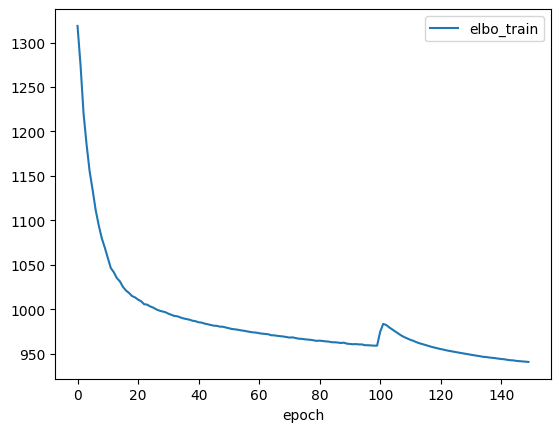

In [11]:
model.train(max_epochs=50, early_stopping=True, batch_size=256)
model.history['elbo_train'].plot()

dict_keys(['lr-Adam', 'kl_weight', 'validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'train_loss', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train'])


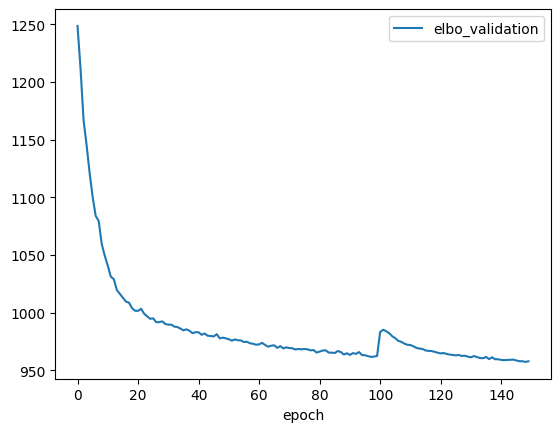

In [12]:
print(model.history.keys())
if 'elbo_validation' in model.history:
    model.history['elbo_validation'].plot()

## Save latent representation and model

In [15]:
adata.obsm['X_totalVI'] = model.get_latent_representation()
rna_norm, protein_denoised = model.get_normalized_expression(return_mean=True, return_numpy=True)
adata.layers['totalVI_normalized'] = rna_norm
adata.obsm['protein_denoised'] = protein_denoised

model.save(MODELS_DIR / 'totalvi_covid', overwrite=True)
adata.write_h5ad(BASE_PATH / 'data' / 'processed' / 'covid_totalvi.h5ad')

In [14]:
adata

AnnData object with n_obs × n_vars = 69090 × 2092
    obs: 'sample_id', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'full_clustering', 'initial_clustering', 'Resample', 'Collection_Day', 'Sex', 'Age_interval', 'Swab_result', 'Status', 'Smoker', 'Status_on_day_collection', 'Status_on_day_collection_summary', 'Days_from_onset', 'Site', 'time_after_LPS', 'Worst_Clinical_Status', 'Outcome', 'patient_id', '_scvi_labels', '_scvi_batch'
    var: 'feature_types', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'leiden', 'neighbors', 'pca', 'umap', 'protein_names', '_scvi_uuid', '_scvi_manager_uuid'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap', 'protein_expression', 'X_totalVI', 'protein_denoised'
    layers: 'raw', 'counts', 'totalVI_normalized'